# TP Python 3 : Géotraitement vectoriel & régressions

**Géoinformatique II — Université de Lausanne**

---

Ce TP Python est le pendant numérique du **TP QGIS 3**. Tu vas reproduire les mêmes opérations de géotraitement vectoriel en Python, puis appliquer des modèles de régression sur les résultats.

| Partie | Bibliothèque | Ce que tu apprendras |
|--------|-------------|----------------------|
| **1. Sélection & extraction** | `geopandas` | Sélectionner des entités par attribut, dissoudre, découper |
| **2. Zones tampons** | `geopandas` / `shapely` | Créer des buffers, définir la zone urbaine (ZDB, ZU) |
| **3. Superposition** | `geopandas` / `shapely` | Union, différence, intersection → WUI |
| **4. Du vecteur au raster** | `rasterio` | Rasteriser des couches vectorielles |
| **5. Régressions** | `scikit-learn` | Régression logistique et linéaire sur données spatiales |

> 🔗 **Lien avec le TP QGIS 3** : tu vas recréer en Python le même résultat que dans QGIS —
> la **zone d'interface habitat-forêt (WUI)** du district bernois de _Frutigen-Niedersimmental_.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

import rasterio
from rasterio.transform import from_bounds
from rasterio.crs import CRS
from rasterio.features import rasterize

from scipy.ndimage import distance_transform_edt

import geopandas as gpd

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, mean_absolute_error, r2_score)


In [2]:
# -------------------------------------------------------
# Chargement des données vectorielles depuis tp3.gpkg
# -------------------------------------------------------
GPKG_PATH = "tp3.gpkg"
CRS_REF   = 'EPSG:21781'   # CH1903 / LV03

foret     = gpd.read_file(GPKG_PATH, layer='Foret').to_crs(CRS_REF)
buildings = gpd.read_file(GPKG_PATH, layer='Buildings').to_crs(CRS_REF)
roads     = gpd.read_file(GPKG_PATH, layer='Roads').to_crs(CRS_REF)
communes  = gpd.read_file(GPKG_PATH, layer='Communes').to_crs(CRS_REF)
districts = gpd.read_file(GPKG_PATH, layer='Districts').to_crs(CRS_REF)

print("Couches vectorielles chargées depuis tp3.gpkg :")
for name, gdf in [
    ('Foret',     foret),
    ('Buildings', buildings),
    ('Roads',     roads),
    ('Communes',  communes),
    ('Districts', districts),
]:
    geom_type = gdf.geometry.geom_type.iloc[0]
    print(f"  {name:12s}: {len(gdf):7d} entités | CRS: EPSG:{gdf.crs.to_epsg()} | géométrie: {geom_type}")


Couches vectorielles chargées depuis tp3.gpkg :
  Foret       :   13461 entités | CRS: EPSG:21781 | géométrie: MultiPolygon
  Buildings   :  373399 entités | CRS: EPSG:21781 | géométrie: MultiPolygon
  Roads       :  112567 entités | CRS: EPSG:21781 | géométrie: MultiLineString
  Communes    :    8868 entités | CRS: EPSG:21781 | géométrie: MultiPolygon
  Districts   :     233 entités | CRS: EPSG:21781 | géométrie: MultiPolygon


---
## Partie 1 — Sélection et extraction

Dans le TP QGIS 3, nous avons commencé par sélectionner les districts bernois de
_Frutigen-Niedersimmental_ et _Obersimmental-Saanen_, les avons fusionnés pour
définir le périmètre d'étude, puis avons découpé les autres couches dans ce périmètre.

En Python avec **geopandas**, les équivalents sont :

| Outil QGIS | Équivalent Python |
|---|---|
| Sélection par expression | `gdf[gdf['col'].str.contains(...)]` |
| Fusionner les entités | `gdf.dissolve()` |
| Couper (*Clip*) | `gpd.clip(layer, mask)` |

### 1.1 Sélection des districts et fusion (étapes 2a/2b)


On sélectionne les districts par expression (équivalent du filtre SQL `"NAME" ILIKE '...'`
dans QGIS), puis on les **fusionne en une seule entité** (`dissolve`) pour
définir le périmètre global de la zone d'étude.


Districts sélectionnés (1) :
  • Frutigen-Niedersimmental

Zone d'étude fusionnée : 1 polygone
  Aire totale  : 1349.1 km²
  Périmètre    : 205.5 km


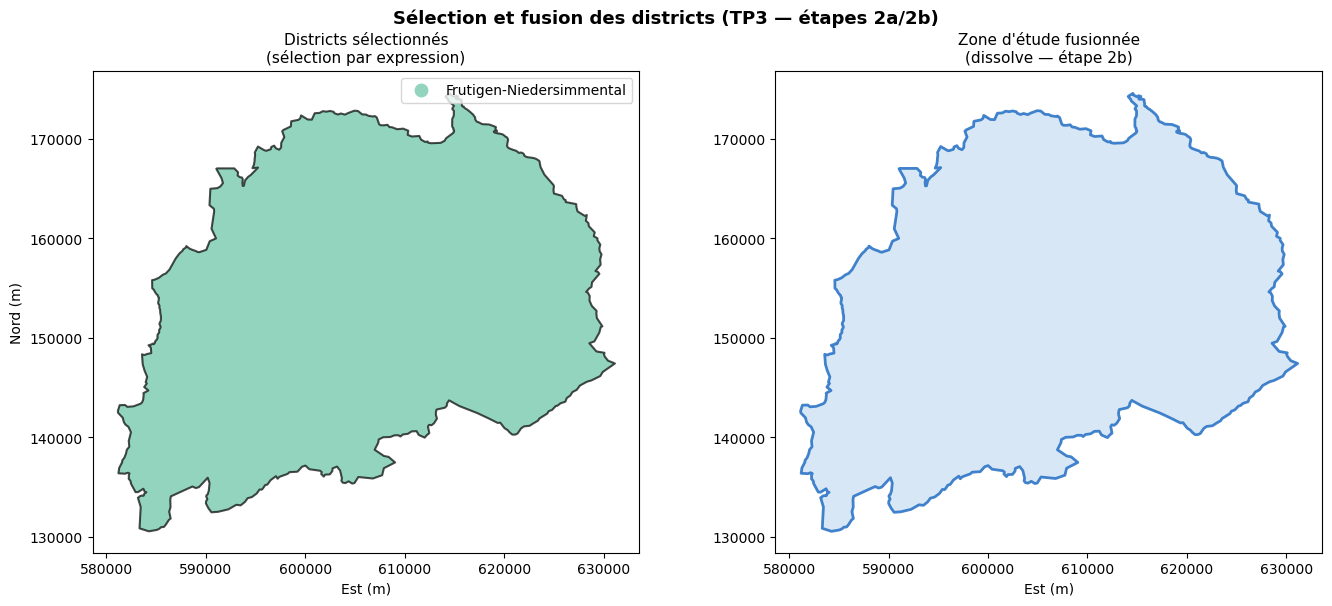

In [3]:
# -------------------------------------------------------
# 2a — Sélection par expression (= filtre SQL dans QGIS)
# -------------------------------------------------------
study_districts = districts[
    districts['NAME'].str.contains(
        'Frutigen-Niedersimmental|Obersimmental-Saanen',
        case=False, na=False
    )
].copy()

print(f"Districts sélectionnés ({len(study_districts)}) :")
for _, row in study_districts.iterrows():
    print(f"  • {row['NAME']}")

# -------------------------------------------------------
# 2b — Fusionner les entités (= dissolve / Fusionner dans QGIS)
# -------------------------------------------------------
study_area = study_districts.dissolve().reset_index(drop=True)[['geometry']]

print(f"\nZone d'étude fusionnée : 1 polygone")
print(f"  Aire totale  : {study_area.geometry.area.iloc[0] / 1e6:.1f} km²")
print(f"  Périmètre    : {study_area.geometry.length.iloc[0] / 1e3:.1f} km")

# -------------------------------------------------------
# Visualisation
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

study_districts.plot(ax=axes[0], column='NAME', cmap='Set2',
                     edgecolor='black', linewidth=1.5, alpha=0.7, legend=True)
axes[0].set_title('Districts sélectionnés\n(sélection par expression)', fontsize=11)
axes[0].set_xlabel('Est (m)')
axes[0].set_ylabel('Nord (m)')

study_area.plot(ax=axes[1], facecolor='#cfe2f3', edgecolor='#1565c0',
                linewidth=2, alpha=0.8)
axes[1].set_title('Zone d\'étude fusionnée\n(dissolve — étape 2b)', fontsize=11)
axes[1].set_xlabel('Est (m)')

plt.suptitle('Sélection et fusion des districts (TP3 — étapes 2a/2b)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 1.2 Découpage des couches (étape 2c)

Une fois le périmètre défini, on découpe toutes les couches avec **`gpd.clip()`**,
l'équivalent de l'outil **Couper** (*Clip*) dans QGIS.
Cela garantit que les géotraitements suivants ne portent que sur la zone d'étude.


Découpage des couches à la zone d'étude...

Résultat du découpage :
  Forêt       :    409 entités
  Bâtiments   :   2680 entités
  Routes      :    806 entités
  Communes    :     48 entités


/tmp/ipykernel_479775/2914653568.py:38: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper right', fontsize=9)


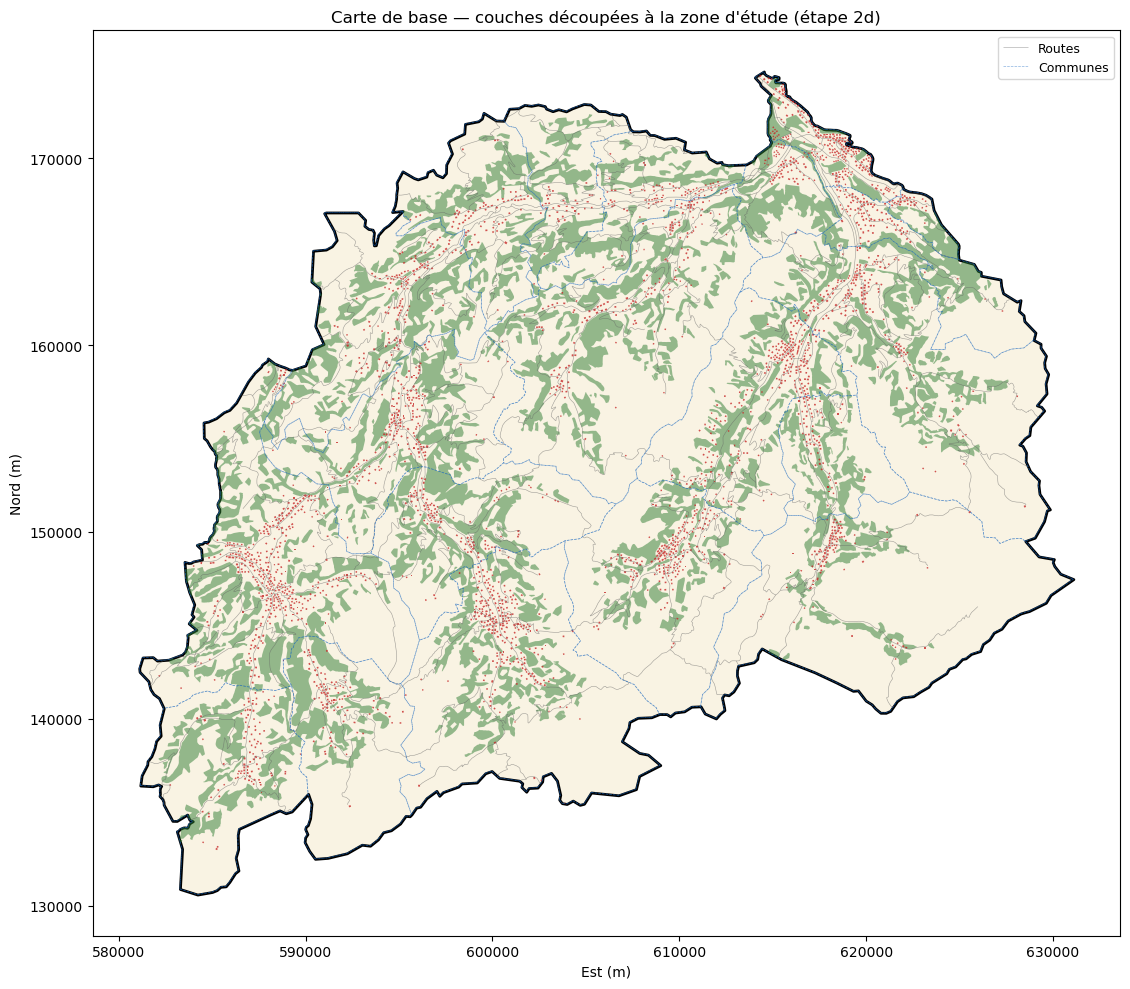

In [4]:
# -------------------------------------------------------
# 2c — Découpage (= outil Clip dans QGIS)
# -------------------------------------------------------
print("Découpage des couches à la zone d'étude...")

foret_clip     = gpd.clip(foret,     study_area).reset_index(drop=True)
buildings_clip = gpd.clip(buildings, study_area).reset_index(drop=True)
roads_clip     = gpd.clip(roads,     study_area).reset_index(drop=True)
communes_clip  = gpd.clip(communes,  study_area).reset_index(drop=True)

print("\nRésultat du découpage :")
for name, gdf in [
    ('Forêt',      foret_clip),
    ('Bâtiments',  buildings_clip),
    ('Routes',     roads_clip),
    ('Communes',   communes_clip),
]:
    print(f"  {name:12s}: {len(gdf):6d} entités")

# -------------------------------------------------------
# Carte de base découpée (étape 2d dans QGIS)
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 10))

study_area.plot(ax=ax, facecolor='#f9f3e3', edgecolor='black', linewidth=2, zorder=1)
foret_clip.plot(ax=ax, color='#2e7d32', alpha=0.5, label='Forêt', zorder=2)
buildings_clip.plot(ax=ax, color='#c62828', alpha=0.8, markersize=0.3,
                    label='Bâtiments', zorder=3)
roads_clip.plot(ax=ax, color='#616161', linewidth=0.4, alpha=0.6,
                label='Routes', zorder=4)
communes_clip.plot(ax=ax, facecolor='none', edgecolor='#1565c0',
                   linewidth=0.5, linestyle='--', alpha=0.5,
                   label='Communes', zorder=5)

ax.set_title('Carte de base — couches découpées à la zone d\'étude (étape 2d)', fontsize=12)
ax.set_xlabel('Est (m)')
ax.set_ylabel('Nord (m)')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


---
## Partie 2 — Zones tampons (Buffer)

Les zones tampons permettent de définir des zones de proximité autour d'entités.
Dans QGIS, nous avons utilisé l'outil **Zone tampon** pour :

1. **Zone Densément Bâtie (ZDB)** — buffer `+75 m` sur les bâtiments (regroupé),
   puis buffer `−75 m` pour conserver uniquement les zones densément bâties
2. **Emprise des routes** — buffer de `6 m` (= moitié de la largeur de 12 m)

| Outil QGIS | Équivalent Python |
|---|---|
| Zone tampon (Buffer) | `.buffer(distance)` sur `geometry` |
| Regrouper le résultat | `.unary_union` (fusionne en une seule géométrie) |

### 2.1 ZDB — Zone Densément Bâtie (étape 3a)


/tmp/ipykernel_479775/3863927220.py:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  buf_pos = buildings_clip.geometry.buffer(75).unary_union   # buffer + dissolve


Étape 1 : buffer +75 m sur les bâtiments (regroupé)...
Étape 2 : buffer −75 m pour garder uniquement les zones denses (ZDB)...
  ZDB : aire totale = 32.30 km²

Buffer routes (6 m)...


/tmp/ipykernel_479775/3863927220.py:18: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  roads_buf_geom = roads_clip.geometry.buffer(6).unary_union


  Routes bufferisées : aire = 15.05 km²


/tmp/ipykernel_479775/3863927220.py:33: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axes[0].legend(fontsize=8)
/tmp/ipykernel_479775/3863927220.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=8)
/tmp/ipykernel_479775/3863927220.py:43: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axes[1].legend(fontsize=8)


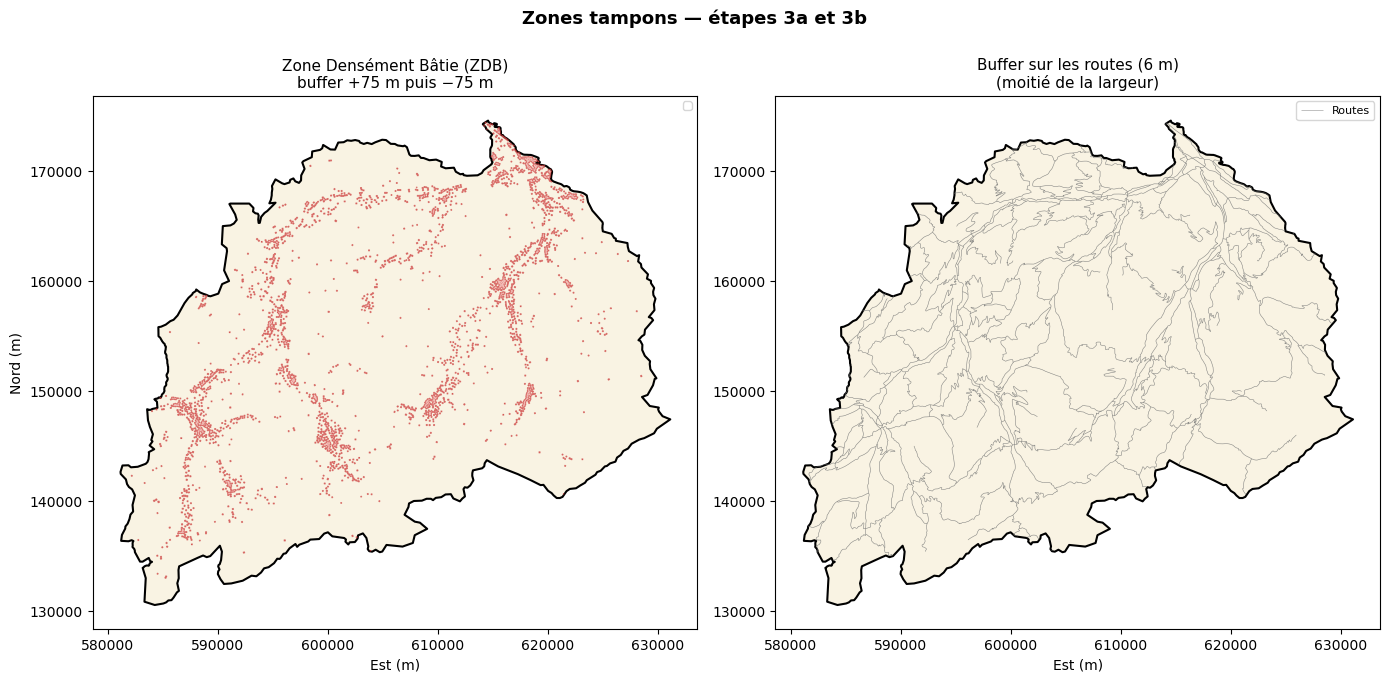

In [5]:
# -------------------------------------------------------
# 3a — Zone Densément Bâtie (ZDB)
#   Étape 1 : buffer +75 m sur les bâtiments, regroupé (unary_union)
#   Étape 2 : buffer −75 m pour éliminer les zones peu denses
# -------------------------------------------------------
print("Étape 1 : buffer +75 m sur les bâtiments (regroupé)...")
buf_pos = buildings_clip.geometry.buffer(75).unary_union   # buffer + dissolve

print("Étape 2 : buffer −75 m pour garder uniquement les zones denses (ZDB)...")
zdb_geom = buf_pos.buffer(-75)
zdb = gpd.GeoDataFrame(geometry=[zdb_geom], crs=CRS_REF)
print(f"  ZDB : aire totale = {zdb_geom.area / 1e6:.2f} km²")

# -------------------------------------------------------
# 3b — Buffer routes (6 m = moitié de la largeur totale de 12 m)
# -------------------------------------------------------
print("\nBuffer routes (6 m)...")
roads_buf_geom = roads_clip.geometry.buffer(6).unary_union
roads_buf = gpd.GeoDataFrame(geometry=[roads_buf_geom], crs=CRS_REF)
print(f"  Routes bufferisées : aire = {roads_buf_geom.area / 1e6:.2f} km²")

# -------------------------------------------------------
# Visualisation
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

study_area.plot(ax=axes[0], facecolor='#f9f3e3', edgecolor='black', linewidth=1.5)
buildings_clip.plot(ax=axes[0], color='#c62828', alpha=0.5, markersize=0.5,
                    label='Bâtiments')
zdb.plot(ax=axes[0], facecolor='#ef9a9a', edgecolor='#c62828',
         linewidth=0.8, alpha=0.5, label='ZDB (±75 m)')
axes[0].set_title('Zone Densément Bâtie (ZDB)\nbuffer +75 m puis −75 m', fontsize=11)
axes[0].legend(fontsize=8)
axes[0].set_xlabel('Est (m)')
axes[0].set_ylabel('Nord (m)')

study_area.plot(ax=axes[1], facecolor='#f9f3e3', edgecolor='black', linewidth=1.5)
roads_clip.plot(ax=axes[1], color='#616161', linewidth=0.4, alpha=0.7,
                label='Routes')
roads_buf.plot(ax=axes[1], facecolor='#b0bec5', edgecolor='none',
               alpha=0.6, label='Buffer routes (6 m)')
axes[1].set_title('Buffer sur les routes (6 m)\n(moitié de la largeur)', fontsize=11)
axes[1].legend(fontsize=8)
axes[1].set_xlabel('Est (m)')

plt.suptitle('Zones tampons — étapes 3a et 3b', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Partie 3 — Superposition (Union, Différence, Intersection)

Ces outils permettent de combiner plusieurs couches pour créer de nouvelles entités.
C'est l'étape centrale du TP pour produire la **WUI** (Wildland-Urban Interface).

| Outil QGIS | Équivalent Python (shapely) |
|---|---|
| Union | `geom_a.union(geom_b)` |
| Différence | `geom_a.difference(geom_b)` |
| Intersection | `geom_a.intersection(geom_b)` |

### 3.1 Zone Urbaine (ZU) = ZDB ∪ routes (étape 4a)
### 3.2 Zone à risque = Buffer(ZU, 80 m) − ZU (étape 4b)
### 3.3 WUI = zone à risque ∩ Forêt (étape 4c)


4a — Union : ZDB ∪ routes bufferisées → Zone Urbaine (ZU)...
  Zone Urbaine (ZU) : aire = 46.66 km²
4b — Buffer 80 m + Différence → zone de risque incendie...
  Zone à risque (bande 80 m hors ZU) : aire = 233.50 km²
4c — Intersection zone risque ∩ Forêt → WUI...


/tmp/ipykernel_479775/149571014.py:22: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  foret_union = foret_clip.geometry.unary_union


  WUI : aire = 46.21 km²
  WUI représente 15.5 % de la surface forestière


/tmp/ipykernel_479775/149571014.py:45: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axes[0].legend(loc='upper right', fontsize=8, title='Couches')
/tmp/ipykernel_479775/149571014.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(loc='upper right', fontsize=8, title='Couches')
/tmp/ipykernel_479775/149571014.py:55: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axes[1].legend(loc='upper right', fontsize=8, title='Couches')
/tmp/ipykernel_479775/149571014.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with

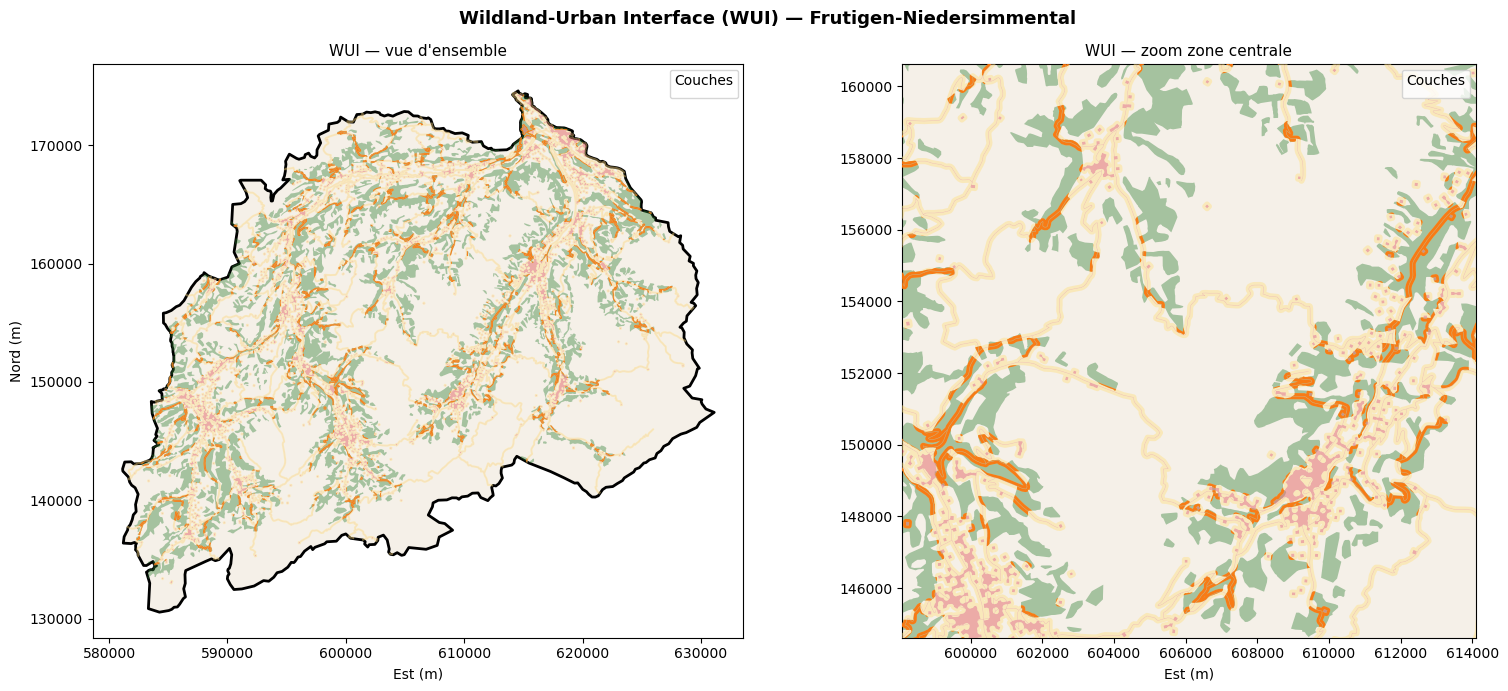

In [6]:
# -------------------------------------------------------
# 4a — Union ZDB ∪ routes bufferisées → Zone Urbaine (ZU)
# -------------------------------------------------------
print("4a — Union : ZDB ∪ routes bufferisées → Zone Urbaine (ZU)...")
zu_geom = zdb_geom.union(roads_buf_geom)
zu = gpd.GeoDataFrame(geometry=[zu_geom], crs=CRS_REF)
print(f"  Zone Urbaine (ZU) : aire = {zu_geom.area / 1e6:.2f} km²")

# -------------------------------------------------------
# 4b — Buffer 80 m autour de ZU + Différence → zone de risque incendie
# -------------------------------------------------------
print("4b — Buffer 80 m + Différence → zone de risque incendie...")
zu_buf_80 = zu_geom.buffer(80)
zone_risque_geom = zu_buf_80.difference(zu_geom)
zone_risque = gpd.GeoDataFrame(geometry=[zone_risque_geom], crs=CRS_REF)
print(f"  Zone à risque (bande 80 m hors ZU) : aire = {zone_risque_geom.area / 1e6:.2f} km²")

# -------------------------------------------------------
# 4c — Intersection zone risque ∩ Forêt → WUI
# -------------------------------------------------------
print("4c — Intersection zone risque ∩ Forêt → WUI...")
foret_union = foret_clip.geometry.unary_union
wui_geom = zone_risque_geom.intersection(foret_union)
wui = gpd.GeoDataFrame(geometry=[wui_geom], crs=CRS_REF)
print(f"  WUI : aire = {wui_geom.area / 1e6:.2f} km²")
print(f"  WUI représente {wui_geom.area / foret_union.area * 100:.1f} % de la surface forestière")

# -------------------------------------------------------
# Carte finale — WUI (vue d'ensemble + zoom)
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax in axes:
    study_area.plot(ax=ax, facecolor='#f5f0e8', edgecolor='black', linewidth=2, zorder=1)
    foret_clip.plot(ax=ax, color='#2e7d32', alpha=0.4, label='Forêt', zorder=2)
    zu.plot(ax=ax, facecolor='#e57373', edgecolor='none', alpha=0.55,
            label='Zone Urbaine (ZU)', zorder=3)
    zone_risque.plot(ax=ax, facecolor='#ffe082', edgecolor='none', alpha=0.45,
                     label='Zone à risque (80 m)', zorder=4)
    wui.plot(ax=ax, facecolor='#ff6d00', edgecolor='none', alpha=0.85,
             label='WUI', zorder=5)

axes[0].set_title('WUI — vue d\'ensemble', fontsize=11)
axes[0].set_xlabel('Est (m)'); axes[0].set_ylabel('Nord (m)')
axes[0].legend(loc='upper right', fontsize=8, title='Couches')

# Zoom au centre pour mieux voir le WUI
b = study_area.total_bounds
cx, cy = (b[0]+b[2])/2, (b[1]+b[3])/2
zoom = 8000
axes[1].set_xlim(cx - zoom, cx + zoom)
axes[1].set_ylim(cy - zoom, cy + zoom)
axes[1].set_title('WUI — zoom zone centrale', fontsize=11)
axes[1].set_xlabel('Est (m)')
axes[1].legend(loc='upper right', fontsize=8, title='Couches')

plt.suptitle('Wildland-Urban Interface (WUI) — Frutigen-Niedersimmental',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Partie 3 — Régression linéaire sur des données de votation

### 3.1 Contexte et objectif

Dans les parties précédentes, tu as réalisé des géotraitements vectoriels.
Dans cette partie, on s'intéresse à une question différente : peut-on **expliquer**
ou **prédire** le résultat d'une votation à partir d'une autre ?

Nous disposons de deux résultats de votations fédérales suisses à l'échelle communale :

| Votation | Date | Description courte |
|---|---|---|
| **Loi Climat (LCI)** | juin 2023 | Loi sur la protection du climat et l'innovation énergétique |
| **Initiative 10 millions** | juin 2026 | « Pas de Suisse à 10 millions ! » (limitation de la croissance démographique) |

Ces deux objets ont des orientations politiques **opposées** : les communes qui ont
fortement soutenu la Loi Climat sont-elles aussi celles qui ont fortement refusé
l'Initiative 10 millions ? C'est une hypothèse géographique que la régression
linéaire va permettre de tester et de quantifier.

> **Ce que tu vas apprendre :**
> - Charger et nettoyer des données tabulaires avec `pandas`
> - Calculer et interpréter le **coefficient de corrélation de Pearson** (r)
> - Ajuster une **régression linéaire** et lire son équation
> - Interpréter le **coefficient de détermination R²**
> - Analyser les **résidus** pour identifier des communes atypiques


In [7]:
import pandas as pd
from scipy import stats

# -------------------------------------------------------
# Chargement des deux fichiers de votation
# -------------------------------------------------------
v23_raw = pd.read_csv('votation_2023.csv', sep=';')
v26_raw = pd.read_csv('votation_2026.csv', sep=';')

# Filtre : niveau communal uniquement
# Loi Climat (LCI) = proposal_id 6630
# Initiative 10 millions     = proposal_id 6860
lci  = v23_raw[(v23_raw['region_type'] == 'municipality') &
               (v23_raw['proposal_id'] == 6630)].copy()
m10  = v26_raw[(v26_raw['region_type'] == 'municipality') &
               (v26_raw['proposal_id'] == 6860)].copy()

# Calcul du taux de oui (%) dans chaque commune
lci['oui_pct_lci'] = lci['yes_votes_count'] / lci['cast_votes_count'] * 100
m10['oui_pct_m10'] = m10['yes_votes_count'] / m10['cast_votes_count'] * 100

# Jointure sur l'identifiant communal (region_id)
df = lci[['region_id', 'region_name', 'parent_canton_name', 'oui_pct_lci']].merge(
     m10[['region_id', 'oui_pct_m10']], on='region_id')

# On ne garde que les communes avec assez de votants (évite les petits villages)
df = df[df['region_id'].notna()].dropna()

print(f"Communes retenues : {len(df)}")
print()
print(f"Loi Climat (LCI)       — taux de OUI : "
      f"moy={df['oui_pct_lci'].mean():.1f}%  "
      f"[{df['oui_pct_lci'].min():.1f}% – {df['oui_pct_lci'].max():.1f}%]")
print(f"Initiative 10 millions — taux de OUI : "
      f"moy={df['oui_pct_m10'].mean():.1f}%  "
      f"[{df['oui_pct_m10'].min():.1f}% – {df['oui_pct_m10'].max():.1f}%]")
print()
df[['region_name', 'parent_canton_name', 'oui_pct_lci', 'oui_pct_m10']].sort_values(
    'oui_pct_lci', ascending=False).head(8)


Communes retenues : 2099

Loi Climat (LCI)       — taux de OUI : moy=50.6%  [7.5% – 82.4%]
Initiative 10 millions — taux de OUI : moy=52.1%  [16.3% – 90.4%]



,region_name,parent_canton_name,oui_pct_lci,oui_pct_m10
835,Kammersrohr,Soleure,82.352941,50.000000
191,Bern,Berne,80.909246,16.305500
1665,Lausanne,Vaud,80.109941,24.132421
711,Fribourg,Fribourg,78.203343,24.197248
1676,Rivaz,Vaud,77.941176,35.757576
2045,Troinex,Genève,77.923628,29.643388
1827,Vevey,Vaud,77.859277,25.667115
720,Villars-sur-Glâne,Fribourg,77.321814,28.903487


### 3.2 Exploration des distributions

Avant de modéliser, on regarde la forme de chaque variable séparément,
puis leur relation conjointe dans un **nuage de points**.


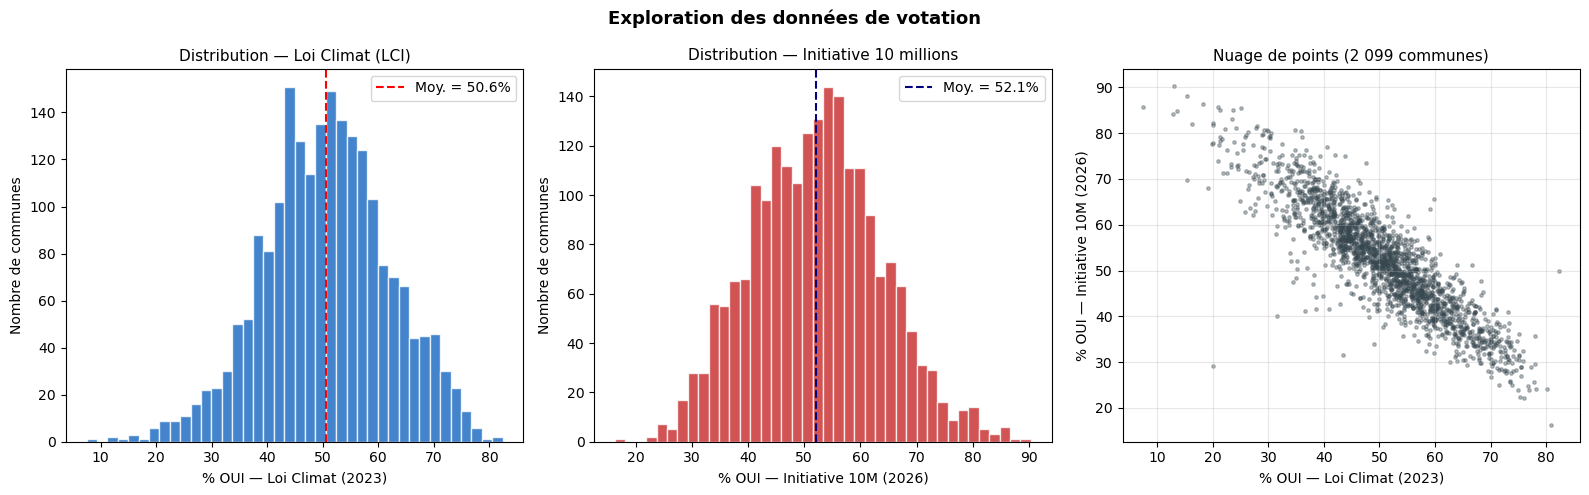

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogramme LCI
axes[0].hist(df['oui_pct_lci'], bins=40, color='#1565c0', alpha=0.8, edgecolor='white')
axes[0].axvline(df['oui_pct_lci'].mean(), color='red', linewidth=1.5, linestyle='--',
                label=f"Moy. = {df['oui_pct_lci'].mean():.1f}%")
axes[0].set_xlabel('% OUI — Loi Climat (2023)')
axes[0].set_ylabel('Nombre de communes')
axes[0].set_title('Distribution — Loi Climat (LCI)', fontsize=11)
axes[0].legend()

# Histogramme 10M
axes[1].hist(df['oui_pct_m10'], bins=40, color='#c62828', alpha=0.8, edgecolor='white')
axes[1].axvline(df['oui_pct_m10'].mean(), color='navy', linewidth=1.5, linestyle='--',
                label=f"Moy. = {df['oui_pct_m10'].mean():.1f}%")
axes[1].set_xlabel('% OUI — Initiative 10M (2026)')
axes[1].set_ylabel('Nombre de communes')
axes[1].set_title('Distribution — Initiative 10 millions', fontsize=11)
axes[1].legend()

# Premier nuage de points
axes[2].scatter(df['oui_pct_lci'], df['oui_pct_m10'],
                s=6, alpha=0.35, color='#37474f')
axes[2].set_xlabel('% OUI — Loi Climat (2023)')
axes[2].set_ylabel('% OUI — Initiative 10M (2026)')
axes[2].set_title('Nuage de points (2 099 communes)', fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Exploration des données de votation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.3 Corrélation de Pearson

La **corrélation de Pearson** (notée *r*) mesure la force et le sens d'une relation
**linéaire** entre deux variables continues :

$$r = \frac{\sum_{i}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_i(x_i-\bar{x})^2}\,\sqrt{\sum_i(y_i-\bar{y})^2}}$$

| Valeur de *r* | Interprétation |
|---|---|
| +1 | Relation linéaire positive parfaite |
| +0.7 à +1 | Forte corrélation positive |
| 0 | Aucune relation linéaire |
| −0.7 à −1 | Forte corrélation négative |
| −1 | Relation linéaire négative parfaite |

> ⚠️ **Attention** : une corrélation forte ne prouve pas une **causalité**.
> Elle indique seulement que les deux variables varient de façon coordonnée.


In [9]:
r, p_value = stats.pearsonr(df['oui_pct_lci'], df['oui_pct_m10'])
print(f"Corrélation de Pearson (r)  : {r:.3f}")
print(f"p-value                     : {p_value:.2e}")
print()
if abs(r) > 0.7:
    force = "forte"
elif abs(r) > 0.4:
    force = "modérée"
else:
    force = "faible"
sens = "négative" if r < 0 else "positive"
print(f"→ Corrélation {force} et {sens}")
print()
print("Interprétation substantielle :")
print("  Les communes qui ont fortement soutenu la Loi Climat")
print("  tendent à rejeter massivement l'Initiative 10 millions,")
print("  et vice versa. Cela reflète une structure politique")
print("  gauche/vert ↔ droite/conservateur stable dans l'espace.")


Corrélation de Pearson (r)  : -0.891
p-value                     : 0.00e+00

→ Corrélation forte et négative

Interprétation substantielle :
  Les communes qui ont fortement soutenu la Loi Climat
  tendent à rejeter massivement l'Initiative 10 millions,
  et vice versa. Cela reflète une structure politique
  gauche/vert ↔ droite/conservateur stable dans l'espace.


### 3.4 Régression linéaire et coefficient R²

La **régression linéaire** va plus loin que la corrélation : elle ajuste une droite
$$\hat{y} = a \cdot x + b$$
qui permet de **prédire** *y* (% OUI Initiative 10M) à partir de *x* (% OUI Loi Climat).

- **Pente *a*** : de combien varie *y* quand *x* augmente d'un point
- **Intercept *b*** : valeur prédite de *y* quand *x* = 0

Le **coefficient de détermination R²** mesure la part de variance de *y*
expliquée par le modèle :

$$R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2} \in [0,\,1]$$

| R² | Interprétation |
|---|---|
| 1.0 | Le modèle explique 100 % de la variance — ajustement parfait |
| 0.8 | Bon modèle, 80 % de la variance expliquée |
| 0.5 | Modèle moyen |
| 0.0 | Le modèle n'explique rien (équivalent à prédire la moyenne) |

> R² = r² pour une régression à une seule variable explicative.


Équation de la droite de régression :
  % OUI 10M = -0.907 × (% OUI LCI) + 98.05

R²   = 0.794  → le modèle explique 79.4 % de la variance
r    = -0.891  (corrélation de Pearson)

Interprétation de la pente :
  Quand le % OUI à la Loi Climat augmente de 1 point,
  le % OUI à l'Initiative 10M varie de -0.91 points en moyenne.


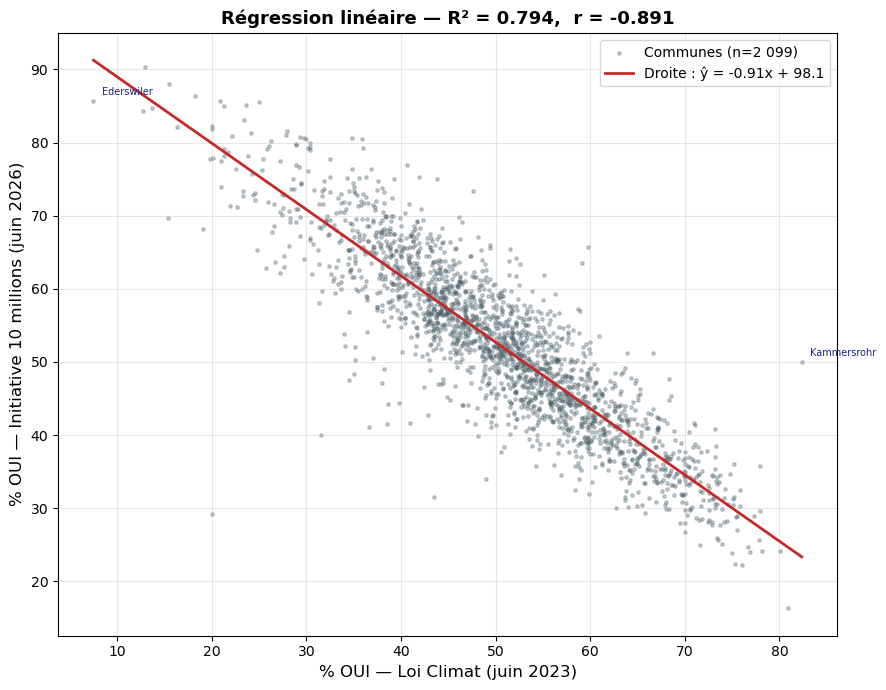

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_reg = df[['oui_pct_lci']].values   # feature : % OUI Loi Climat
y_reg = df['oui_pct_m10'].values     # cible   : % OUI Initiative 10M

model = LinearRegression()
model.fit(X_reg, y_reg)

a = model.coef_[0]        # pente
b = model.intercept_      # intercept
y_pred = model.predict(X_reg)
r2 = r2_score(y_reg, y_pred)

print(f"Équation de la droite de régression :")
print(f"  % OUI 10M = {a:.3f} × (% OUI LCI) + {b:.2f}")
print()
print(f"R²   = {r2:.3f}  → le modèle explique {r2*100:.1f} % de la variance")
print(f"r    = {r2**0.5 * (1 if a > 0 else -1):.3f}  (corrélation de Pearson)")
print()
print(f"Interprétation de la pente :")
print(f"  Quand le % OUI à la Loi Climat augmente de 1 point,")
print(f"  le % OUI à l'Initiative 10M varie de {a:+.2f} points en moyenne.")

# -------------------------------------------------------
# Nuage de points + droite de régression
# -------------------------------------------------------
x_line = np.linspace(df['oui_pct_lci'].min(), df['oui_pct_lci'].max(), 200)
y_line = a * x_line + b

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(df['oui_pct_lci'], df['oui_pct_m10'],
           s=6, alpha=0.30, color='#455a64', label='Communes (n=2 099)')
ax.plot(x_line, y_line, color='#c62828', linewidth=2,
        label=f'Droite : ŷ = {a:.2f}x + {b:.1f}')
ax.set_xlabel('% OUI — Loi Climat (juin 2023)', fontsize=12)
ax.set_ylabel('% OUI — Initiative 10 millions (juin 2026)', fontsize=12)
ax.set_title(f'Régression linéaire — R² = {r2:.3f},  r = {r:.3f}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Annotations des deux extrêmes
top_lci = df.nlargest(1, 'oui_pct_lci').iloc[0]
low_lci = df.nsmallest(1, 'oui_pct_lci').iloc[0]
for row in [top_lci, low_lci]:
    ax.annotate(row['region_name'],
                xy=(row['oui_pct_lci'], row['oui_pct_m10']),
                xytext=(6, 4), textcoords='offset points', fontsize=7, color='#1a237e')

plt.tight_layout()
plt.show()


### 3.5 Analyse des résidus

Les **résidus** sont les écarts entre les valeurs observées et les valeurs prédites par le modèle :
$$e_i = y_i - \hat{y}_i$$

Les communes avec de **grands résidus positifs** votent *plus* pour l'Initiative 10M
que ce que leur vote pour la Loi Climat ne laisserait prévoir.
Les communes avec de **grands résidus négatifs** votent *moins* pour l'Initiative 10M
que prévu — elles s'écartent du clivage gauche/droite habituel.

Un bon modèle linéaire produit des résidus :
- **centrés sur zéro** (pas de biais systématique)
- **sans structure** (pas de tendance résiduelle)


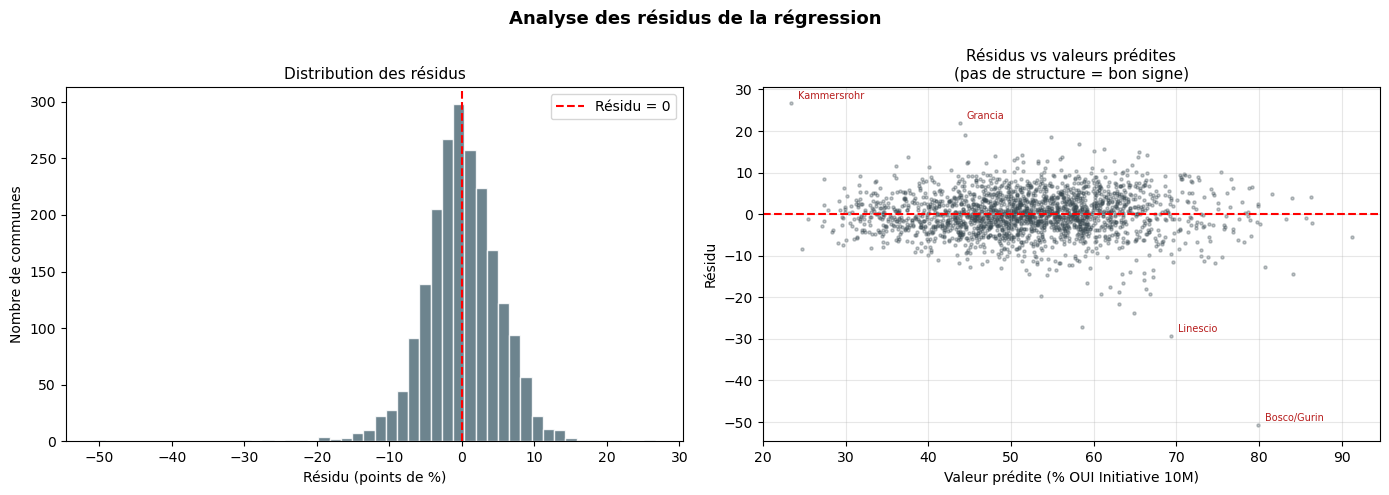

Communes les plus atypiques (résidus positifs — plus pro-10M que prévu) :
         region_name parent_canton_name  oui_pct_lci  oui_pct_m10  residual
         Kammersrohr            Soleure         82.4         50.0      26.7
             Grancia             Tessin         59.8         65.7      21.9
Chavannes-sur-Moudon               Vaud         59.1         63.5      19.0
            Bedretto             Tessin         47.6         73.4      18.6
              Romoos            Lucerne         43.9         75.1      16.8

Communes les plus atypiques (résidus négatifs — moins pro-10M que prévu) :
   region_name parent_canton_name  oui_pct_lci  oui_pct_m10  residual
   Bosco/Gurin             Tessin         20.0         29.2     -50.7
      Linescio             Tessin         31.6         40.0     -29.4
       La Praz               Vaud         43.5         31.6     -27.0
      Novalles               Vaud         36.6         41.1     -23.8
Bioley-Magnoux               Vaud         38

In [17]:
df['residual'] = df['oui_pct_m10'] - y_pred

# Top communes avec résidus les plus extrêmes
top_pos = df.nlargest(5, 'residual')[['region_name', 'parent_canton_name',
                                       'oui_pct_lci', 'oui_pct_m10', 'residual']]
top_neg = df.nsmallest(5, 'residual')[['region_name', 'parent_canton_name',
                                        'oui_pct_lci', 'oui_pct_m10', 'residual']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme des résidus
axes[0].hist(df['residual'], bins=50, color='#546e7a', alpha=0.85, edgecolor='white')
axes[0].axvline(0, color='red', linewidth=1.5, linestyle='--', label='Résidu = 0')
axes[0].set_xlabel('Résidu (points de %)')
axes[0].set_ylabel('Nombre de communes')
axes[0].set_title('Distribution des résidus', fontsize=11)
axes[0].legend()

# Résidus vs valeurs prédites
axes[1].scatter(y_pred, df['residual'], s=5, alpha=0.3, color='#37474f')
axes[1].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Valeur prédite (% OUI Initiative 10M)')
axes[1].set_ylabel('Résidu')
axes[1].set_title('Résidus vs valeurs prédites\n(pas de structure = bon signe)', fontsize=11)
axes[1].grid(True, alpha=0.3)

# Annotations des communes les plus atypiques
for _, row in pd.concat([top_pos.head(2), top_neg.head(2)]).iterrows():
    axes[1].annotate(row['region_name'],
                     xy=(row['oui_pct_m10'] - row['residual'], row['residual']),
                     xytext=(5, 3), textcoords='offset points', fontsize=7, color='#b71c1c')

plt.suptitle('Analyse des résidus de la régression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Communes les plus atypiques (résidus positifs — plus pro-10M que prévu) :")
print(top_pos.round(1).to_string(index=False))
print()
print("Communes les plus atypiques (résidus négatifs — moins pro-10M que prévu) :")
print(top_neg.round(1).to_string(index=False))


---
## Récapitulatif

### Parties 1–3 — Géotraitement vectoriel (parallèle du TP QGIS 3)

| Opération QGIS | Code Python clé |
|---|---|
| Sélection par expression | `gdf[gdf['col'].str.contains(...)]` |
| Fusionner (dissolve) | `gdf.dissolve()` |
| Couper (Clip) | `gpd.clip(layer, mask)` |
| Zone tampon (Buffer) | `.buffer(dist)` + `.unary_union` |
| Double buffer (ZDB) | `.buffer(+75).unary_union` puis `.buffer(-75)` |
| Union / Différence / Intersection | `geom_a.union/difference/intersection(geom_b)` |

### Partie 4 — Régression linéaire sur données de votation

| Étape | Code clé |
|---|---|
| Charger et filtrer | `pd.read_csv(...)` + filtre `proposal_id` + `region_type` |
| Calculer le taux | `yes_votes_count / cast_votes_count * 100` |
| Joindre les tables | `df_a.merge(df_b, on='region_id')` |
| Corrélation de Pearson | `stats.pearsonr(x, y)` → `(r, p_value)` |
| Régression linéaire | `LinearRegression().fit(X, y)` → `.coef_`, `.intercept_` |
| Coefficient R² | `r2_score(y, y_pred)` |
| Résidus | `y - y_pred` |

**Concepts clés :**

| Indicateur | Signification |
|---|---|
| **r** (Pearson) | Force et sens de la relation linéaire entre x et y ∈ [−1, 1] |
| **R²** | Part de la variance de y expliquée par le modèle ∈ [0, 1] |
| **Pente *a*** | Variation de y pour +1 unité de x |
| **Résidus** | Écarts entre valeurs observées et prédites — révèlent les cas atypiques |

> **Règle clé** : R² dit *combien* le modèle explique ;
> les résidus disent *où* il se trompe.
> Les deux sont aussi importants que la droite elle-même.
